# 1. Eksplorasi Data

In [20]:
# ==========================================
# 1. IMPORT PUSTAKA / LIBRARY
# ==========================================
# Pustaka manipulasi matriks dan tabel data
import numpy as np
import pandas as pd

# Pustaka untuk rendering visualisasi
import seaborn as sns
import matplotlib.pyplot as plt

# Modul Scikit-Learn untuk standardisasi, pemodelan, dan evaluasi klaster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# 2. LOAD DATASET
# ==========================================
# Menggunakan variabel statis untuk lokasi file (Best Practice)
FILE_CLUSTERING = '/content/drive/MyDrive/MLUTS/clusteringmidterm.csv'

# Memuat data ke dalam objek DataFrame khusus klastering
df_cluster = pd.read_csv(FILE_CLUSTERING)

# ==========================================
# 3. PREVIEW DATA
# ==========================================
print("=== Inspeksi Awal Dataset Clustering ===")
print(f"Total dimensi data: {df_cluster.shape[0]} baris x {df_cluster.shape[1]} kolom")
print("-" * 50)

# Menampilkan cuplikan data
display(df_cluster.head())

=== Inspeksi Awal Dataset Clustering ===
Total dimensi data: 8950 baris x 18 kolom
--------------------------------------------------


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Menampilkan informasi umum dataset (tipe data, nilai non-null)

In [22]:
# ==========================================
# 4. DATA PROFILING & INSPEKSI AWAL
# ==========================================
print("=== A. Ringkasan Struktur dan Tipe Data ===")
# info() dipanggil langsung tanpa display() karena sudah otomatis mencetak output
df_cluster.info()

print("\n=== B. Pengecekan Nilai Kosong (Missing Values) ===")
# Menampilkan jumlah data yang kosong dalam bentuk tabel agar rapi
tabel_kosong = df_cluster.isna().sum().to_frame(name='Jumlah Missing Value')
display(tabel_kosong[tabel_kosong['Jumlah Missing Value'] > 0]) # Hanya tampilkan jika ada yang kosong

print("\n=== C. Statistik Deskriptif Numerik ===")
# Menggunakan .T (Transpose) agar tabel deskripsi melebar ke bawah, lebih mudah dibaca
display(df_cluster.describe().T)

=== A. Ringkasan Struktur dan Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX         

,Jumlah Missing Value
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313



=== C. Statistik Deskriptif Numerik ===


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


##==========================================
## 5. STATISTIK DESKRIPTIF MENDALAM
##==========================================

In [23]:

print("=== Ringkasan Distribusi & Sebaran Data ===")

# Menghitung statistik dasar dan melakukan transpose agar kolom menjadi baris
tabel_statistik = df_cluster.describe().T

# Menambahkan efek visual gradasi warna (heatmap) ke dalam tabel DataFrame
# Semakin gelap warnanya, semakin tinggi angkanya
tabel_berwarna = tabel_statistik.style.background_gradient(cmap='YlGnBu')

display(tabel_berwarna)

=== Ringkasan Distribusi & Sebaran Data ===


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.138560
BALANCE_FREQUENCY,8950.000000,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.000000
CASH_ADVANCE,8950.000000,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.211760
PURCHASES_FREQUENCY,8950.000000,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.500000


##==========================================
## 6. PENANGANAN MISSING VALUES & ELIMINASI FITUR
## ==========================================

In [24]:

print("=== Status Missing Values (Sebelum Imputasi) ===")
# Menggunakan .isna() sebagai alternatif .isnull()
cek_kosong = df_cluster.isna().sum()
# Memfilter output agar HANYA menampilkan kolom yang memiliki nilai kosong
display(cek_kosong[cek_kosong > 0])

# Menentukan target kolom yang butuh diimputasi
kolom_bermasalah = ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

# Menghitung median untuk masing-masing kolom dan menyimpannya dalam format dictionary
# Pendekatan ini lebih bersih dan 100% aman dari FutureWarning Pandas versi terbaru
kamus_imputasi = {kolom: df_cluster[kolom].median() for kolom in kolom_bermasalah}
df_cluster = df_cluster.fillna(value=kamus_imputasi)

# Membuang fitur CUST_ID dan menyimpan hasilnya ke DataFrame baru khusus modeling
# Menggunakan parameter columns=[] yang lebih eksplisit dibanding axis=1
df_clean = df_cluster.drop(columns=['CUST_ID'])

print("\n=== Status Missing Values (Setelah Imputasi) ===")
# Kita ubah cara ceknya: Hitung total keseluruhan sisa nilai kosong di dataset
total_kosong_sekarang = df_clean.isna().sum().sum()

print(f"Total sel data yang masih kosong: {total_kosong_sekarang}")
if total_kosong_sekarang == 0:
    print("✅ Pengecekan aman! Dataset sudah bersih dan siap masuk tahap pemodelan.")
else:
    print("⚠️ Peringatan: Masih ada data yang kosong!")

=== Status Missing Values (Sebelum Imputasi) ===


,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313



=== Status Missing Values (Setelah Imputasi) ===
Total sel data yang masih kosong: 0
✅ Pengecekan aman! Dataset sudah bersih dan siap masuk tahap pemodelan.


# ==========================================
# 7. PENANGANAN OUTLIER (CLIPPING PERSENTIL 99)
# ==========================================
# Menyimpan salinan data mentah untuk perbandingan visual nanti

In [25]:

df_sebelum_clip = df_clean.copy()

# MENGHITUNG DAN MEMOTONG DALAM 1 LANGKAH (VECTORIZED)
# Menghitung batas persentil 99 untuk semua kolom sekaligus, lalu memangkasnya (clip)
# Cara ini jauh lebih efisien di Python dibandingkan menggunakan for-loop
batas_persentil_99 = df_clean.quantile(0.99)
df_clean = df_clean.clip(upper=batas_persentil_99, axis=1)

print("✅ Proses capping/clipping nilai ekstrem pada persentil ke-99 berhasil dieksekusi!")



✅ Proses capping/clipping nilai ekstrem pada persentil ke-99 berhasil dieksekusi!


## ==========================================
## VISUALISASI EFEK CLIPPING (BEFORE vs AFTER)
## ==========================================

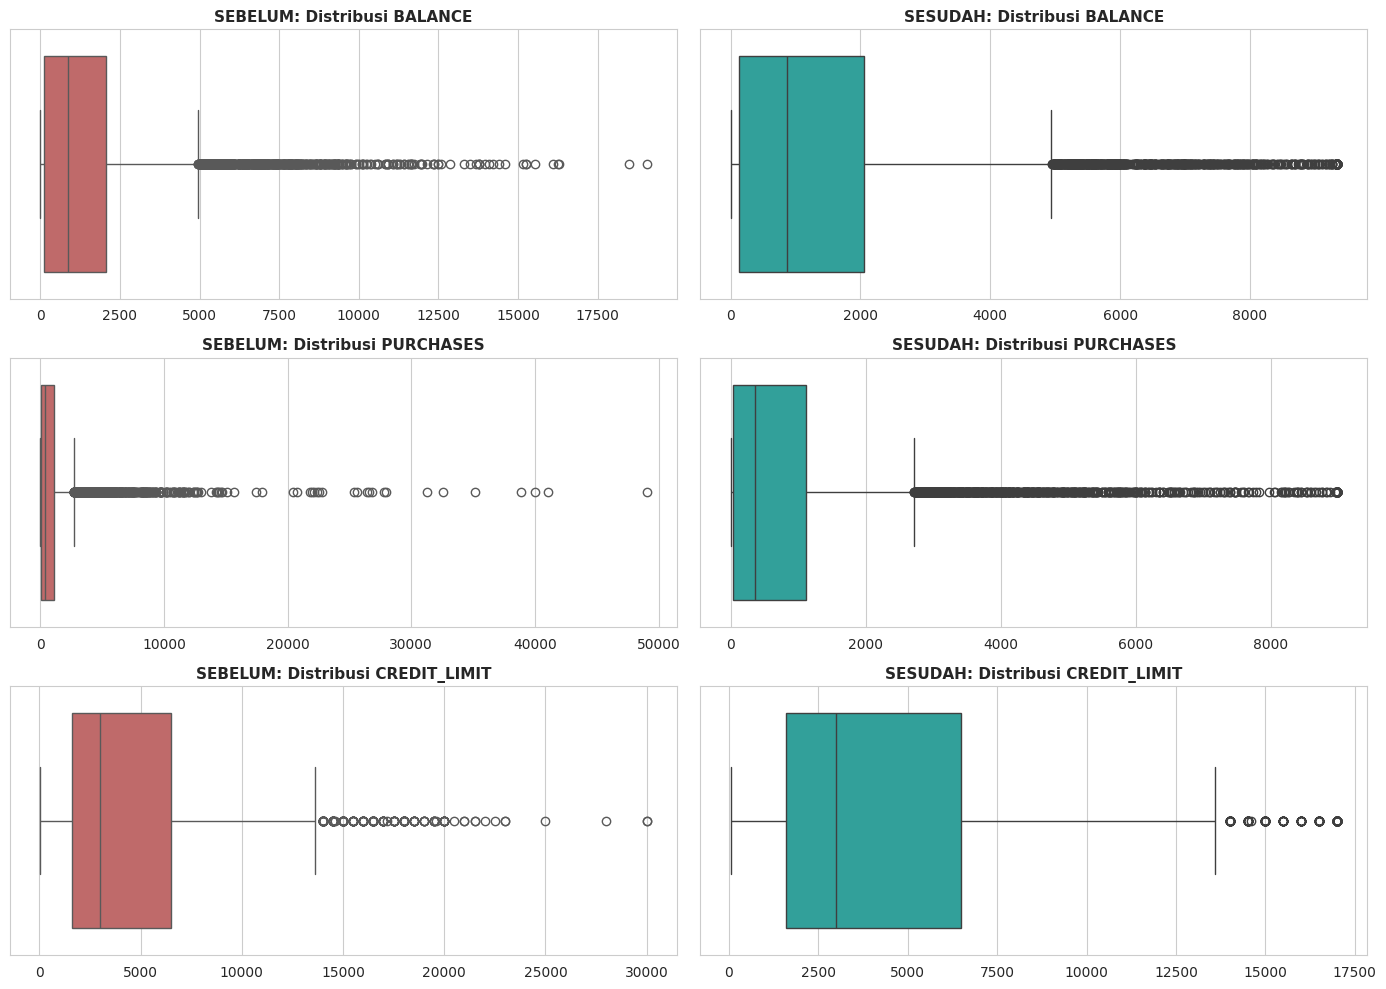

In [26]:

# Memilih atribut finansial utama untuk dievaluasi
atribut_evaluasi = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']

# Membuat kanvas grid berukuran 3 baris x 2 kolom
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
sns.set_style("whitegrid")

for i, fitur in enumerate(atribut_evaluasi):
    # Plot Kiri: SEBELUM CLIPPING (Warna Merah Bata, Orientasi Horizontal)
    sns.boxplot(x=df_sebelum_clip[fitur], color='indianred', ax=ax[i, 0])
    ax[i, 0].set_title(f'SEBELUM: Distribusi {fitur}', fontweight='bold', fontsize=11)
    ax[i, 0].set_xlabel('')

    # Plot Kanan: SESUDAH CLIPPING (Warna Hijau Tosca, Orientasi Horizontal)
    sns.boxplot(x=df_clean[fitur], color='lightseagreen', ax=ax[i, 1])
    ax[i, 1].set_title(f'SESUDAH: Distribusi {fitur}', fontweight='bold', fontsize=11)
    ax[i, 1].set_xlabel('')

# Memastikan jarak antar grafik tidak tumpang tindih
plt.tight_layout()
plt.show()

### =============================
### 8. VERIFIKASI AKHIR DATASET
### =============================

In [27]:

# Memastikan kembali kolom CUST_ID terhapus (errors='ignore' mencegah program error jika kolom sudah hilang sebelumnya)
df_clean = df_clean.drop(columns=['CUST_ID'], errors='ignore')

print("=== Cuplikan 5 Baris Data Siap Masuk Tahap Klastering ===")
print(f"Dimensi akhir: {df_clean.shape[0]} baris x {df_clean.shape[1]} fitur")
print("-" * 55)

# Menampilkan 5 baris pertama
display(df_clean.head())

=== Cuplikan 5 Baris Data Siap Masuk Tahap Klastering ===
Dimensi akhir: 8950 baris x 17 fitur
-------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2.0,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0.0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12.0,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1.0,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1.0,1200.0,678.334763,244.791237,0.000000,12


### ==========================================
### 9. STANDARDISASI FITUR (FEATURE SCALING)
### ==========================================

In [28]:
# K-Means sangat sensitif terhadap rentang angka yang berbeda-beda.
# Kita menggunakan Standard Scaler (Z-Score Normalization) agar rata-rata = 0 dan variansi = 1.

# Inisialisasi model scaler dengan penamaan variabel yang lebih spesifik
skala_standar = StandardScaler()

# Melakukan fitting dan transformasi secara bersamaan
matriks_skala = skala_standar.fit_transform(df_clean)

# Merekonstruksi array Numpy kembali menjadi Pandas DataFrame
# Menambahkan argumen 'index' agar urutan baris dijamin 100% sama persis dengan data aslinya
df_standar = pd.DataFrame(
    data=matriks_skala,
    index=df_clean.index,
    columns=df_clean.columns
)

# Menampilkan output yang lebih deskriptif
print("=== Cuplikan Dataset Setelah Standardisasi (Z-Score) ===")
print("Semua kolom kini memiliki skala metrik yang setara.")
print("-" * 55)

display(df_standar.head())

=== Cuplikan Dataset Setelah Standardisasi (Z-Score) ===
Semua kolom kini memiliki skala metrik yang setara.
-------------------------------------------------------


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.762855,-0.249434,-0.551327,-0.489121,-0.427513,-0.527079,-0.806490,-0.678661,-0.707313,-0.685371,-0.557505,-0.579714,-0.977979,-0.642945,-0.493064,-0.525551,0.36068
1,0.844867,0.134325,-0.613881,-0.489121,-0.568588,3.101370,-1.221758,-0.678661,-0.916995,0.593147,0.166685,-0.675130,0.711333,1.089747,0.263656,0.234227,0.36068
2,0.485181,0.518084,-0.106917,0.215778,-0.568588,-0.527079,1.269843,2.673451,-0.916995,-0.685371,-0.557505,-0.102638,0.852109,-0.456289,-0.097377,-0.525551,0.36068
3,0.063883,-1.016953,0.369006,0.877517,-0.568588,-0.411186,-1.014125,-0.399319,-0.916995,-0.259200,-0.376457,-0.627422,0.852109,-0.732573,-0.352859,-0.525551,0.36068
4,-0.367829,0.518084,-0.603389,-0.474534,-0.568588,-0.527079,-1.014125,-0.399319,-0.916995,-0.685371,-0.557505,-0.627422,-0.921669,-0.431298,-0.407659,-0.525551,0.36068


### ==========================================
### 10. EVALUASI K-MEANS: ELBOW METHOD
### ==========================================

In [29]:

nilai_inersia = []
rentang_k = range(1, 11) # Mencoba variasi dari 1 hingga 10 klaster

print("Menghitung inersia untuk berbagai nilai K... Mohon tunggu.")

# Melakukan iterasi pencarian model
for k in rentang_k:
    model_evaluasi = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42 # Seed agar hasil selalu konsisten
    )
    model_evaluasi.fit(df_standar) # Menggunakan df_standar dari cell sebelumnya
    nilai_inersia.append(model_evaluasi.inertia_)

Menghitung inersia untuk berbagai nilai K... Mohon tunggu.


### ==========================================
### VISUALISASI GRAFIK ELBOW
### ==========================================

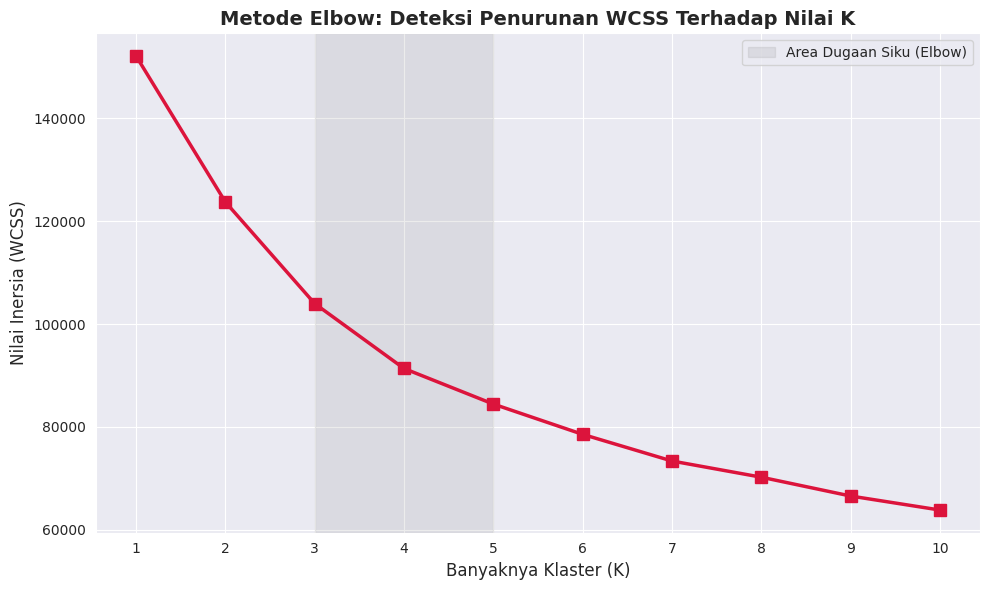

In [30]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Membuat plot dengan marker persegi ('s') berwarna merah gelap ('crimson')
ax.plot(rentang_k, nilai_inersia, marker='s', markersize=8, color='crimson',
        linewidth=2.5, linestyle='-')

# Konfigurasi teks dan label
ax.set_title('Metode Elbow: Deteksi Penurunan WCSS Terhadap Nilai K', fontsize=14, fontweight='bold')
ax.set_xlabel('Banyaknya Klaster (K)', fontsize=12)
ax.set_ylabel('Nilai Inersia (WCSS)', fontsize=12)
ax.set_xticks(rentang_k)

# [EKSTRA] Menambahkan bayangan untuk menandai area pencarian siku (biasanya di k=3 hingga k=5)
ax.axvspan(3, 5, alpha=0.15, color='gray', label='Area Dugaan Siku (Elbow)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### ==========================================
### 11. VALIDASI K-MEANS: SILHOUETTE SCORE
### ==========================================

Mengevaluasi kepadatan dan jarak antar klaster... 

➜ Uji K = 2 | Skor Siluet: 0.3041
➜ Uji K = 3 | Skor Siluet: 0.2564
➜ Uji K = 4 | Skor Siluet: 0.1952
➜ Uji K = 5 | Skor Siluet: 0.1895
➜ Uji K = 6 | Skor Siluet: 0.1997
➜ Uji K = 7 | Skor Siluet: 0.2111
➜ Uji K = 8 | Skor Siluet: 0.2137
➜ Uji K = 9 | Skor Siluet: 0.1964
➜ Uji K = 10 | Skor Siluet: 0.1943
---------------------------------------------
✨ K Terbaik menurut Silhouette adalah K=2 (Skor: 0.3041)


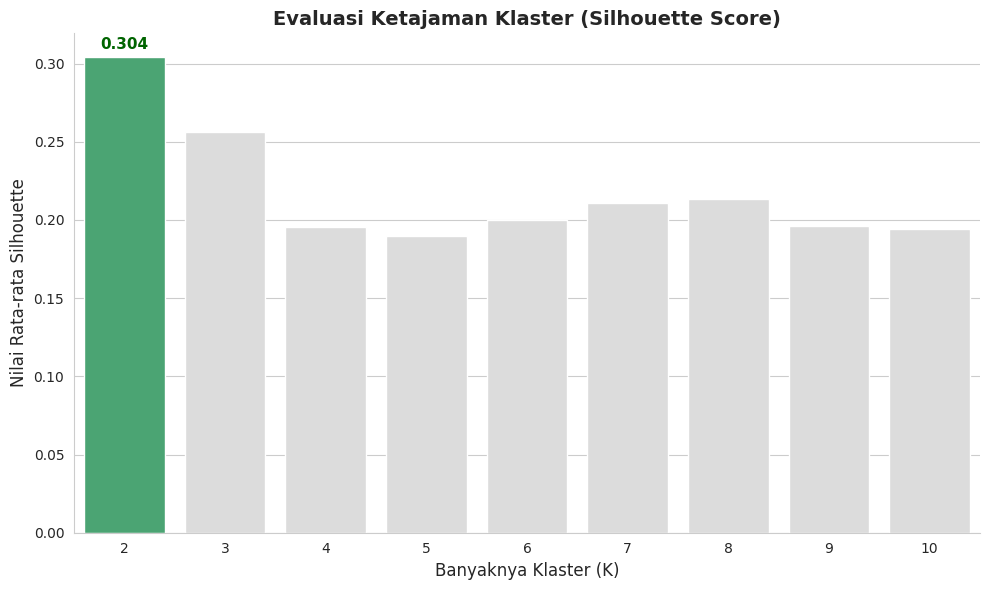

In [31]:
# Menggunakan dictionary untuk menyimpan hasil agar lebih mudah diolah
skor_siluet = {}
rentang_pengujian = range(2, 11) # Silhouette butuh minimal 2 klaster untuk dibandingkan

print("Mengevaluasi kepadatan dan jarak antar klaster... \n")

for k in rentang_pengujian:
    # Inisialisasi dan fitting model K-Means
    model_km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    label_prediksi = model_km.fit_predict(df_standar)

    # Kalkulasi skor rata-rata
    rata_rata_siluet = silhouette_score(df_standar, label_prediksi)
    skor_siluet[k] = rata_rata_siluet

    print(f"➜ Uji K = {k} | Skor Siluet: {rata_rata_siluet:.4f}")

# Konversi ke Pandas Series untuk ekstraksi nilai tertinggi dengan mudah
deret_siluet = pd.Series(skor_siluet)
k_terbaik = deret_siluet.idxmax()
skor_terbaik = deret_siluet.max()

print("-" * 45)
print(f"✨ K Terbaik menurut Silhouette adalah K={k_terbaik} (Skor: {skor_terbaik:.4f})")

# ==========================================
# VISUALISASI ESTATIK SILHOUETTE SCORE
# ==========================================
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Logika desain: Warna abu-abu netral untuk semua bar, KECUALI skor tertinggi diberi warna hijau emerald
warna_dinamis = ['gainsboro' if k != k_terbaik else 'mediumseagreen' for k in deret_siluet.index]

# Membuat barplot
sns.barplot(x=deret_siluet.index, y=deret_siluet.values, palette=warna_dinamis, ax=ax)

# Menambahkan anotasi teks angka persis di atas batang tertinggi agar langsung terbaca
indeks_tertinggi = list(deret_siluet.index).index(k_terbaik)
ax.text(
    x=indeks_tertinggi,
    y=skor_terbaik + 0.003, # Mengangkat posisi teks sedikit ke atas batang
    s=f"{skor_terbaik:.3f}",
    ha='center', va='bottom', fontweight='bold', color='darkgreen', fontsize=11
)

ax.set_title('Evaluasi Ketajaman Klaster (Silhouette Score)', fontsize=14, fontweight='bold')
ax.set_xlabel('Banyaknya Klaster (K)', fontsize=12)
ax.set_ylabel('Nilai Rata-rata Silhouette', fontsize=12)

# Menghilangkan garis tepi atas dan kanan agar grafik terlihat modern
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### ==========================================
### 12. FITTING MODEL UTAMA K-MEANS CLUSTERING
### ==========================================

In [32]:

# Menetapkan jumlah kelompok terbaik berdasarkan hasil uji validasi
JUMLAH_K_TERBAIK = 3

# Inisialisasi algoritma K-Means dengan centroid k-means++ agar konvergensi cepat
model_kmeans_final = KMeans(
    n_clusters=JUMLAH_K_TERBAIK,
    init='k-means++',
    n_init=10,
    random_state=42
)

# Melakukan fitting sekaligus memprediksi label kelompok pada data terstandardisasi
label_klaster_akhir = model_kmeans_final.fit_predict(df_standar)

# Mengintegrasikan kembali label hasil klastering ke DataFrame utama dan skala
df_cluster['Cluster'] = label_klaster_akhir
df_standar['Cluster'] = label_klaster_akhir

print(f"✅ Algoritma K-Means sukses dieksekusi menggunakan konfigurasi {JUMLAH_K_TERBAIK} Klaster.")
print("-" * 65)

# ==========================================
# ANALISIS DISTRIBUSI ANGGOTA KLASTER
# ==========================================
print("📊 Rangkuman Komposisi dan Sebaran Anggota Klaster:")

# Menghitung jumlah total per klaster
cacah_anggota = df_cluster['Cluster'].value_counts().sort_index()

# Menghitung persentase proporsi tiap klaster agar analisis lebih kaya
persentase_anggota = (df_cluster['Cluster'].value_counts(normalize=True).sort_index() * 100)

# Menggabungkan hasil perhitungan ke dalam satu tabel ringkasan
ringkasan_klaster = pd.DataFrame({
    'Jumlah Nasabah': cacah_anggota,
    'Persentase Proporsi (%)': persentase_anggota.round(2)
})
ringkasan_klaster.index.name = 'ID Klaster'

display(ringkasan_klaster)

✅ Algoritma K-Means sukses dieksekusi menggunakan konfigurasi 3 Klaster.
-----------------------------------------------------------------
📊 Rangkuman Komposisi dan Sebaran Anggota Klaster:


,Jumlah Nasabah,Persentase Proporsi (%)
ID Klaster,,
0,1638,18.30
1,5977,66.78
2,1335,14.92


### ==========================================
### 13. PROFILING KLASTER (ANALISIS PERILAKU)
### ==========================================

=== Profil Rata-Rata Karakteristik Tiap Klaster ===


Cluster,0,1,2
BALANCE,3930.108957,779.882679,2174.661023
BALANCE_FREQUENCY,0.958247,0.831938,0.980878
PURCHASES,376.049884,474.450560,4140.016891
ONEOFF_PURCHASES,239.192515,238.266329,2611.535041
INSTALLMENTS_PURCHASES,136.919438,236.516331,1528.931288
CASH_ADVANCE,3824.641661,315.651681,456.541813
PURCHASES_FREQUENCY,0.236756,0.459188,0.941023
ONEOFF_PURCHASES_FREQUENCY,0.107901,0.131024,0.638293
PURCHASES_INSTALLMENTS_FREQUENCY,0.149521,0.338801,0.742912
CASH_ADVANCE_FREQUENCY,0.439420,0.067607,0.064184


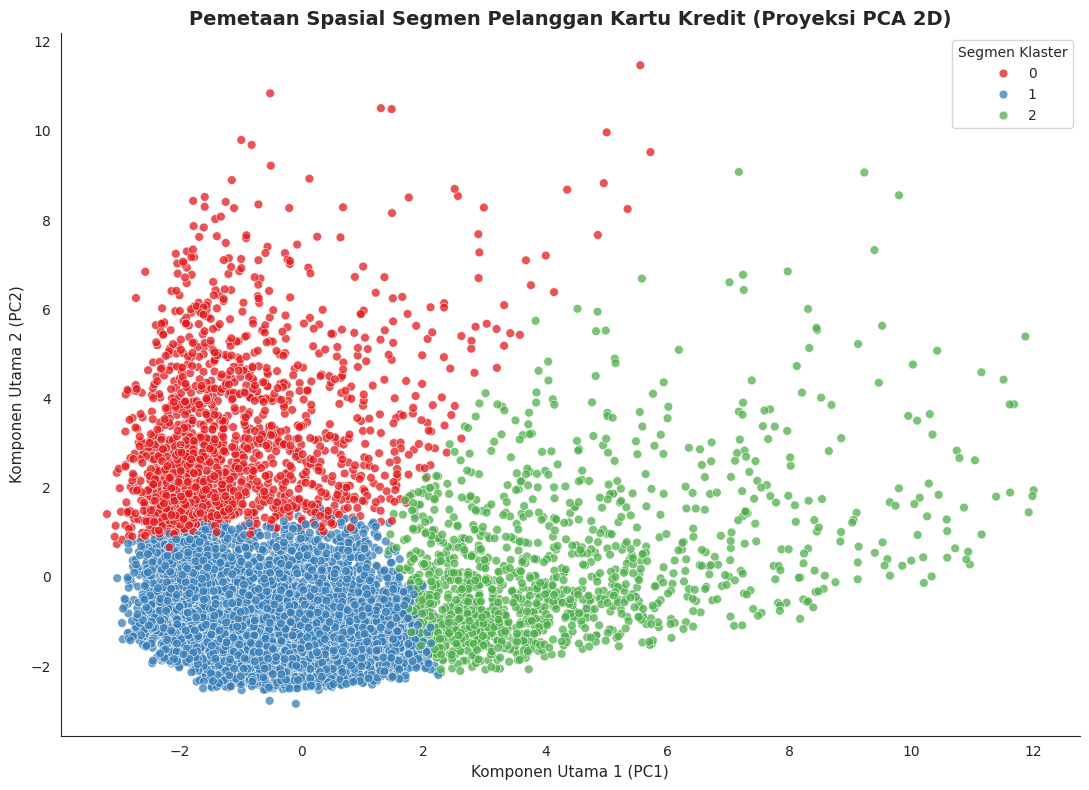

---------------------------------------------------------------------------
💡 Info Akademis: Dua komponen utama PCA ini berhasil merangkum 51.34% dari total informasi/varians dataset asli.


In [33]:
print("=== Profil Rata-Rata Karakteristik Tiap Klaster ===")

# Menghitung rata-rata per kelompok, membuang kolom ID jika masih tersisa
# Menggunakan Transpose (.T) agar daftar fitur memanjang ke bawah (lebih mudah dibaca)
tabel_profil = df_cluster.drop(columns=['CUST_ID'], errors='ignore').groupby('Cluster').mean().T

# Memberikan warna gradasi horizontal berdasarkan nilai antar klaster
tabel_profil_estetik = tabel_profil.style.background_gradient(cmap='YlOrRd', axis=1)
display(tabel_profil_estetik)

# ==========================================
# 14. REDUKSI DIMENSI DENGAN PCA (2D VISUALIZATION)
# ==========================================
# Impor modul PCA dari library Scikit-Learn
from sklearn.decomposition import PCA

# Inisialisasi PCA untuk mengekstraksi 2 komponen utama
reduksi_pca = PCA(n_components=2, random_state=42)

# Mengambil matriks fitur dari df_standar (tanpa menyertakan kolom label 'Cluster')
matriks_fitur_skala = df_standar.drop(columns=['Cluster'], errors='ignore')
koordinat_pca = reduksi_pca.fit_transform(matriks_fitur_skala)

# Menyusun DataFrame hasil proyeksi PCA
df_proyeksi_pca = pd.DataFrame(
    data=koordinat_pca,
    columns=['Principal Component 1', 'Principal Component 2'],
    index=df_standar.index
)
# Menautkan kembali label klaster akhir untuk pemetaan warna (hue)
df_proyeksi_pca['ID_Klaster'] = df_standar['Cluster']

# ==========================================
# VISUALISASI SCATTER PLOT 2D
# ==========================================
sns.set_style("white")
plt.figure(figsize=(11, 8))

# Membuat scatter plot dengan parameter alpha agar titik transparan tidak menumpuk pekat
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='ID_Klaster',
    data=df_proyeksi_pca,
    palette='Set1',
    alpha=0.75,
    s=40
)

# Konfigurasi judul, label, dan legenda grafik
plt.title('Pemetaan Spasial Segmen Pelanggan Kartu Kredit (Proyeksi PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel('Komponen Utama 1 (PC1)', fontsize=11)
plt.ylabel('Komponen Utama 2 (PC2)', fontsize=11)
plt.legend(title='Segmen Klaster', loc='upper right', frameon=True)

# Menghilangkan bingkai atas dan kanan untuk estetika modern
sns.despine()

plt.tight_layout()
plt.show()

# Menampilkan informasi Variance Ratio sebagai bukti analisis akademik tambahan
print("-" * 75)
print(f"💡 Info Akademis: Dua komponen utama PCA ini berhasil merangkum "
      f"{sum(reduksi_pca.explained_variance_ratio_)*100:.2f}% dari total informasi/varians dataset asli.")